# Анализ A/B-теста


**Бизнес-вопрос:** стоит ли компании раскатывать новую страницу на всех пользователей?

**Основная метрика:** Conversion Rate.

```text
Conversion Rate = пользователи с конверсией / все пользователи
```

## 1. Импорт библиотек

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chisquare
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

## 2. Загрузка данных

In [34]:
ab_test = pd.read_csv("../data/raw/ab_test.csv")
countries = pd.read_csv("../data/raw/countries_ab.csv")

print("Размер ab_test:", ab_test.shape)
print("Размер countries:", countries.shape)

Размер ab_test: (294478, 5)
Размер countries: (290584, 2)


In [35]:
ab_test.head()

,id,time,con_treat,page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


In [36]:
countries.head()

,id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


## 3. Обзор данных

Проверим структуру таблиц, типы данных, пропуски и значения в ключевых колонках.

In [37]:
ab_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         294478 non-null  int64
 1   time       294478 non-null  str  
 2   con_treat  294478 non-null  str  
 3   page       294478 non-null  str  
 4   converted  294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [38]:
countries.info()

<class 'pandas.DataFrame'>
RangeIndex: 290584 entries, 0 to 290583
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   id       290584 non-null  int64
 1   country  290584 non-null  str  
dtypes: int64(1), str(1)
memory usage: 4.4 MB


In [39]:
print("Пропуски в ab_test:")
display(ab_test.isna().sum())

print("Пропуски в countries:")
display(countries.isna().sum())

Пропуски в ab_test:


id           0
time         0
con_treat    0
page         0
converted    0
dtype: int64

Пропуски в countries:


id         0
country    0
dtype: int64

In [40]:
print("Группы эксперимента:")
display(ab_test["con_treat"].value_counts())

print("Версии страниц:")
display(ab_test["page"].value_counts())

print("Значения целевой переменной converted:")
display(ab_test["converted"].value_counts())

Группы эксперимента:


con_treat
treatment    147276
control      147202
Name: count, dtype: int64

Версии страниц:


page
old_page    147239
new_page    147239
Name: count, dtype: int64

Значения целевой переменной converted:


converted
0    259241
1     35237
Name: count, dtype: int64

### Наблюдения

В датасете есть пользователи из двух групп: `control` и `treatment`.

Целевая переменная - `converted`:

- `0` означает, что пользователь не совершил конверсию;
- `1` означает, что пользователь совершил конверсию.

Перед расчетом эффекта нужно проверить, корректно ли был проведен эксперимент.

## 4. Проверка корректности эксперимента

### 4.1. Уникальные пользователи и дубликаты

In [41]:
total_rows = ab_test.shape[0]
unique_users = ab_test["id"].nunique()

print("Всего строк:", total_rows)
print("Уникальных пользователей:", unique_users)
print("Лишних строк из-за повторяющихся user_id:", total_rows - unique_users)

Всего строк: 294478
Уникальных пользователей: 290584
Лишних строк из-за повторяющихся user_id: 3894


In [42]:
duplicated_users = (
    ab_test["id"]
    .value_counts()
    .reset_index()
)

duplicated_users.columns = ["id", "rows_count"]

num_duplicated_users = duplicated_users[duplicated_users["rows_count"] > 1].shape[0]
print("Пользователей, которые встречаются больше одного раза:", num_duplicated_users)

duplicated_users[duplicated_users["rows_count"] > 1].head()

Пользователей, которые встречаются больше одного раза: 3894


,id,rows_count
0,767017,2
1,656468,2
2,773693,2
3,733976,2
4,704650,2


### 4.2. Пользователи, попавшие в несколько групп

In [43]:
groups_per_user = (
    ab_test
    .groupby("id")["con_treat"]
    .nunique()
    .reset_index(name="groups_count")
)

display(groups_per_user["groups_count"].value_counts())

users_in_multiple_groups = groups_per_user.loc[
    groups_per_user["groups_count"] > 1,
    "id"
]

print("Пользователей в нескольких группах:", users_in_multiple_groups.nunique())

groups_count
1    288689
2      1895
Name: count, dtype: int64

Пользователей в нескольких группах: 1895


In [44]:
ab_test[
    ab_test["id"].isin(users_in_multiple_groups)
].sort_values("id").head(10)

,id,time,con_treat,page,converted
207211,630320,02:43.6,control,old_page,0
255753,630320,27:37.2,treatment,old_page,0
39852,630805,01:15.1,control,old_page,0
73599,630805,45:39.0,treatment,old_page,0
213377,630871,00:05.2,control,old_page,0
18596,630871,23:01.3,treatment,old_page,0
114320,630887,23:47.4,treatment,new_page,0
28177,630887,34:14.4,control,new_page,0
137766,631008,52:17.1,control,old_page,0
113635,631008,07:48.1,treatment,old_page,0


Пользователь не должен одновременно находиться в `control` и `treatment`.  
Если пользователь попал в обе группы, его конверсию нельзя надежно связать с одной конкретной версией страницы.

Такие пользователи полностью удаляются из анализа.

### 4.3. Проверка соответствия группы и страницы

In [45]:
pd.crosstab(ab_test["con_treat"], ab_test["page"])

page,new_page,old_page
con_treat,,
control,1928,145274
treatment,145311,1965


Ожидаемое соответствие:

```text
control   -> old_page
treatment -> new_page
```

Строки с некорректными парами группа-страница будут удалены.

## 5. Очистка данных

In [46]:
# Удаляем пользователей, которые попали сразу в несколько групп
ab_clean = ab_test[
    ~ab_test["id"].isin(users_in_multiple_groups)
].copy()

print("Строк после удаления пользователей из нескольких групп:", ab_clean.shape[0])
print("Уникальных пользователей:", ab_clean["id"].nunique())

Строк после удаления пользователей из нескольких групп: 290688
Уникальных пользователей: 288689


In [47]:
# Оставляем только корректные пары группа-страница
ab_clean = ab_clean[
    ((ab_clean["con_treat"] == "control") & (ab_clean["page"] == "old_page")) |
    ((ab_clean["con_treat"] == "treatment") & (ab_clean["page"] == "new_page"))
].copy()

print("Строк после удаления некорректных пар группа-страница:", ab_clean.shape[0])
print("Уникальных пользователей:", ab_clean["id"].nunique())
print("Оставшихся дубликатов пользователей:", ab_clean.shape[0] - ab_clean["id"].nunique())

Строк после удаления некорректных пар группа-страница: 288690
Уникальных пользователей: 288689
Оставшихся дубликатов пользователей: 1


In [48]:
# Полностью удаляем оставшихся пользователей-дубликатов
duplicated_ids_clean = ab_clean.loc[
    ab_clean["id"].duplicated(keep=False),
    "id"
]

ab_clean = ab_clean[
    ~ab_clean["id"].isin(duplicated_ids_clean)
].copy()

print("Финальное количество строк:", ab_clean.shape[0])
print("Финальное количество уникальных пользователей:", ab_clean["id"].nunique())

Финальное количество строк: 288688
Финальное количество уникальных пользователей: 288688


In [49]:
# Добавляем информацию о стране пользователя
ab_clean = ab_clean.merge(countries, on="id", how="left")

print("Пропуски после объединения со странами:")
display(ab_clean.isna().sum())

display(ab_clean.head())

Пропуски после объединения со странами:


id           0
time         0
con_treat    0
page         0
converted    0
country      0
dtype: int64

,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [50]:
print("Финальное соответствие групп и страниц:")
display(pd.crosstab(ab_clean["con_treat"], ab_clean["page"]))

print("Финальные размеры групп:")
display(ab_clean["con_treat"].value_counts())

print("Распределение пользователей по странам:")
display(ab_clean["country"].value_counts())

Финальное соответствие групп и страниц:


page,new_page,old_page
con_treat,,
control,0,144300
treatment,144388,0


Финальные размеры групп:


con_treat
treatment    144388
control      144300
Name: count, dtype: int64

Распределение пользователей по странам:


country
US    202267
UK     72018
CA     14403
Name: count, dtype: int64

In [51]:
ab_clean.to_csv("../data/processed/ab_test_clean.csv", index=False)

### Итог проверки эксперимента


Выводы:

- были повторяющиеся пользователи;
- 1 895 пользователей попали одновременно в `control` и `treatment`;
- часть строк имела некорректные пары группа-страница;
- пользователи из нескольких групп были удалены;
- некорректные пары группа-страница были удалены;
- оставшиеся дубликаты пользователей были удалены;
- информация о стране была добавлена из второго датасета.

Очищенный датасет используется для расчета конверсии и статистических тестов.

## 6. Расчет базовых метрик

In [52]:
metrics = (
    ab_clean
    .groupby("con_treat")
    .agg(
        users=("id", "nunique"),
        conversions=("converted", "sum")
    )
)

metrics["conversion_rate"] = metrics["conversions"] / metrics["users"]

metrics

,users,conversions,conversion_rate
con_treat,,,
control,144300,17360,0.120305
treatment,144388,17158,0.118833


In [53]:
control_cr = metrics.loc["control", "conversion_rate"]
treatment_cr = metrics.loc["treatment", "conversion_rate"]

absolute_diff = treatment_cr - control_cr
relative_uplift = absolute_diff / control_cr

print(f"Conversion Rate в control: {control_cr:.2%}")
print(f"Conversion Rate в treatment: {treatment_cr:.2%}")
print(f"Абсолютная разница: {absolute_diff * 100:.3f} п.п.")
print(f"Относительный uplift: {relative_uplift:.2%}")

Conversion Rate в control: 12.03%
Conversion Rate в treatment: 11.88%
Абсолютная разница: -0.147 п.п.
Относительный uplift: -1.22%


In [54]:
summary = metrics.copy()
summary["conversion_rate"] = summary["conversion_rate"].map(lambda x: f"{x:.2%}")

summary

,users,conversions,conversion_rate
con_treat,,,
control,144300,17360,12.03%
treatment,144388,17158,11.88%


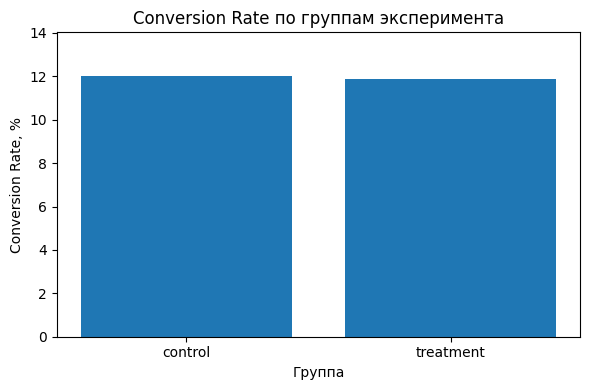

In [55]:
plot_data = metrics.reset_index().copy()
plot_data["conversion_rate_pct"] = plot_data["conversion_rate"] * 100

plt.figure(figsize=(6, 4))
plt.bar(plot_data["con_treat"], plot_data["conversion_rate_pct"])
plt.title("Conversion Rate по группам эксперимента")
plt.xlabel("Группа")
plt.ylabel("Conversion Rate, %")
plt.ylim(0, plot_data["conversion_rate_pct"].max() + 2)
plt.tight_layout()
plt.savefig("../images/conversion_rate_by_group.png", dpi=300)
plt.show()

На описательном уровне группа `treatment` показывает немного более низкую конверсию, чем группа `control`.

Но одной описательной разницы недостаточно для бизнес-решения. Нужно проверить статистическую значимость результата.

## 7. Проверка статистической значимости

Для сравнения двух конверсий используем two-proportion z-test.

Гипотезы:

- H0: conversion rate в `treatment` равен conversion rate в `control`;
- H1: conversion rate в `treatment` отличается от conversion rate в `control`.

Уровень значимости: alpha = 0.05.

In [56]:
count = np.array([
    metrics.loc["control", "conversions"],
    metrics.loc["treatment", "conversions"]
])

nobs = np.array([
    metrics.loc["control", "users"],
    metrics.loc["treatment", "users"]
])

z_stat, p_value = proportions_ztest(count, nobs)

print("z-статистика:", round(z_stat, 4))
print("p-value:", round(p_value, 4))

z-статистика: 1.2191
p-value: 0.2228


In [57]:
alpha = 0.05

if p_value < alpha:
    print("Отвергаем H0: разница статистически значима.")
else:
    print("Не отвергаем H0: разница статистически незначима.")

Не отвергаем H0: разница статистически незначима.


In [58]:
ci_low, ci_high = confint_proportions_2indep(
    count1=metrics.loc["treatment", "conversions"],
    nobs1=metrics.loc["treatment", "users"],
    count2=metrics.loc["control", "conversions"],
    nobs2=metrics.loc["control", "users"],
    method="wald"
)

print("95% доверительный интервал для разницы treatment - control:")
print(f"[{ci_low * 100:.3f}, {ci_high * 100:.3f}] п.п.")

95% доверительный интервал для разницы treatment - control:
[-0.384, 0.089] п.п.


### Интерпретация статистического теста

Группа `treatment` показала немного более низкую конверсию, чем группа `control`.

Однако наблюдаемая разница статистически незначима на уровне 5%.  
95% доверительный интервал включает 0, значит наблюдаемая разница может быть объяснена случайными колебаниями.

Недостаточно статистических оснований утверждать, что новая страница улучшает конверсию.

## 8. Проверка Sample Ratio Mismatch

Ожидаемое распределение трафика: 50% в `control` и 50% в `treatment`.

Гипотезы:

- H0: фактическое распределение групп соответствует ожидаемому 50/50;
- H1: фактическое распределение групп отличается от ожидаемого 50/50.

In [59]:
group_counts = ab_clean["con_treat"].value_counts().sort_index()
group_share = group_counts / group_counts.sum()

srm_table = pd.DataFrame({
    "group": group_counts.index,
    "observed_users": group_counts.values,
    "observed_share": group_share.values
})

srm_table["expected_share"] = 0.5
srm_table

,group,observed_users,observed_share,expected_share
0,control,144300,0.499848,0.5
1,treatment,144388,0.500152,0.5


In [60]:
observed = group_counts.values
expected = np.array([
    group_counts.sum() / 2,
    group_counts.sum() / 2
])

chi2_stat, p_value_srm = chisquare(
    f_obs=observed,
    f_exp=expected
)

print("Chi-square statistic:", round(chi2_stat, 4))
print("p-value:", round(p_value_srm, 4))

if p_value_srm < alpha:
    print("Обнаружен SRM: распределение групп статистически значимо отличается от 50/50.")
else:
    print("SRM не обнаружен: распределение групп соответствует ожидаемому 50/50.")

Chi-square statistic: 0.0268
p-value: 0.8699
SRM не обнаружен: распределение групп соответствует ожидаемому 50/50.


Проверка SRM не выявила статистически значимого отклонения от ожидаемого распределения 50/50.  
Это поддерживает корректность распределения трафика после очистки данных.

## 9. Сегментный анализ по странам

In [61]:
country_metrics = (
    ab_clean
    .groupby(["country", "con_treat"])
    .agg(
        users=("id", "nunique"),
        conversions=("converted", "sum")
    )
    .reset_index()
)

country_metrics["conversion_rate"] = country_metrics["conversions"] / country_metrics["users"]

country_metrics

,country,con_treat,users,conversions,conversion_rate
0,CA,control,7150,851,0.119021
1,CA,treatment,7253,813,0.112092
2,UK,control,36138,4331,0.119846
3,UK,treatment,35880,4351,0.121265
4,US,control,101012,12178,0.120560
5,US,treatment,101255,11994,0.118453


In [62]:
country_test_results = []

for country in sorted(ab_clean["country"].unique()):
    subset = ab_clean[ab_clean["country"] == country]

    test_data_country = (
        subset
        .groupby("con_treat")
        .agg(
            users=("id", "nunique"),
            conversions=("converted", "sum")
        )
    )

    if not {"control", "treatment"}.issubset(test_data_country.index):
        print(f"Пропускаем {country}: нет control или treatment")
        continue

    control_users = test_data_country.loc["control", "users"]
    treatment_users = test_data_country.loc["treatment", "users"]

    control_conversions = test_data_country.loc["control", "conversions"]
    treatment_conversions = test_data_country.loc["treatment", "conversions"]

    count = np.array([control_conversions, treatment_conversions])
    nobs = np.array([control_users, treatment_users])

    z_stat_country, p_value_country = proportions_ztest(count, nobs)

    control_cr_country = control_conversions / control_users
    treatment_cr_country = treatment_conversions / treatment_users

    absolute_diff_country = treatment_cr_country - control_cr_country
    relative_uplift_country = absolute_diff_country / control_cr_country

    country_test_results.append({
        "country": country,
        "control_users": control_users,
        "treatment_users": treatment_users,
        "control_cr": control_cr_country,
        "treatment_cr": treatment_cr_country,
        "absolute_diff": absolute_diff_country,
        "relative_uplift": relative_uplift_country,
        "p_value": p_value_country
    })

country_test_results = pd.DataFrame(country_test_results)
country_test_results["is_significant"] = country_test_results["p_value"] < 0.05

country_test_results

,country,control_users,treatment_users,control_cr,treatment_cr,absolute_diff,relative_uplift,p_value,is_significant
0,CA,7150,7253,0.119021,0.112092,-0.006929,-0.058220,0.193346,False
1,UK,36138,35880,0.119846,0.121265,0.001419,0.011842,0.558660,False
2,US,101012,101255,0.120560,0.118453,-0.002107,-0.017473,0.144208,False


In [63]:
country_results_formatted = country_test_results.copy()

country_results_formatted["control_cr"] = country_results_formatted["control_cr"].map(lambda x: f"{x:.2%}")
country_results_formatted["treatment_cr"] = country_results_formatted["treatment_cr"].map(lambda x: f"{x:.2%}")
country_results_formatted["absolute_diff"] = country_results_formatted["absolute_diff"].map(lambda x: f"{x * 100:.2f} п.п.")
country_results_formatted["relative_uplift"] = country_results_formatted["relative_uplift"].map(lambda x: f"{x:.2%}")
country_results_formatted["p_value"] = country_results_formatted["p_value"].map(lambda x: f"{x:.4f}")

country_results_formatted

,country,control_users,treatment_users,control_cr,treatment_cr,absolute_diff,relative_uplift,p_value,is_significant
0,CA,7150,7253,11.90%,11.21%,-0.69 п.п.,-5.82%,0.1933,False
1,UK,36138,35880,11.98%,12.13%,0.14 п.п.,1.18%,0.5587,False
2,US,101012,101255,12.06%,11.85%,-0.21 п.п.,-1.75%,0.1442,False


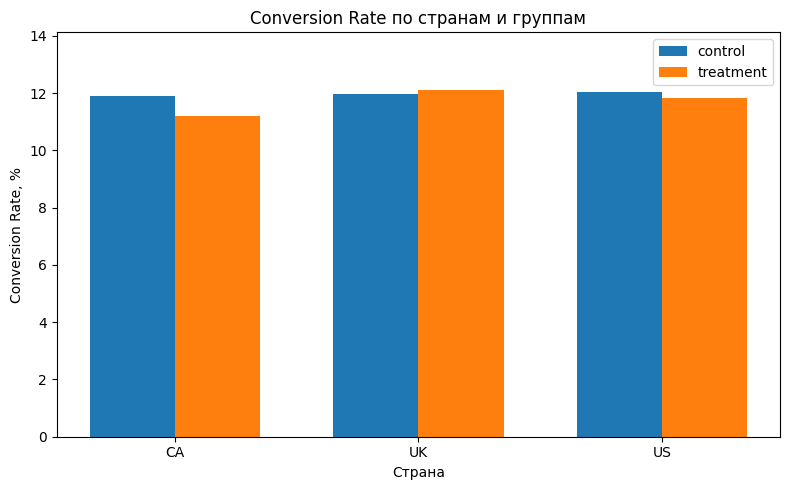

In [64]:
plot_country = country_metrics.copy()
plot_country["conversion_rate_pct"] = plot_country["conversion_rate"] * 100

countries_order = sorted(plot_country["country"].unique())

x = np.arange(len(countries_order))
width = 0.35

control_values = (
    plot_country[plot_country["con_treat"] == "control"]
    .set_index("country")
    .loc[countries_order, "conversion_rate_pct"]
)

treatment_values = (
    plot_country[plot_country["con_treat"] == "treatment"]
    .set_index("country")
    .loc[countries_order, "conversion_rate_pct"]
)

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, control_values, width, label="control")
plt.bar(x + width/2, treatment_values, width, label="treatment")

plt.title("Conversion Rate по странам и группам")
plt.xlabel("Страна")
plt.ylabel("Conversion Rate, %")
plt.xticks(x, countries_order)
plt.legend()
plt.ylim(0, max(control_values.max(), treatment_values.max()) + 2)

plt.tight_layout()
plt.savefig("../images/conversion_rate_by_country.png", dpi=300)
plt.show()

### Интерпретация сегментного анализа

Сегментный анализ не дает убедительных доказательств, что новая страница улучшает конверсию в какой-либо стране.

## 10. Финальная бизнес-рекомендация

На основании текущих результатов A/B-теста новую посадочную страницу **не рекомендуется раскатывать на всех пользователей**.

Причины:

- группа `treatment` не показала более высокую конверсию, чем группа `control`;
- наблюдаемая разница статистически незначима;
- доверительный интервал включает 0;
- сегментный анализ по странам не выявил явного положительного эффекта;
- проверка SRM не выявила проблемы с распределением трафика после очистки.

Рекомендуемое решение: оставить старую страницу и дополнительно исследовать, почему новая версия не улучшила конверсию.